In [3]:
from skimage import io, color
from skimage.morphology import binary_closing, binary_opening
from skimage.morphology import disk
import numpy as np
from skimage import measure
from skimage.color import label2rgb
from scipy.stats import norm
from scipy.spatial import distance
import matplotlib.pyplot as plt

In [5]:
import math
from skimage.transform import rotate
from skimage.transform import EuclideanTransform
from skimage.transform import SimilarityTransform
from skimage.transform import warp
from skimage.transform import swirl

In [4]:
def show_comparison(original, transformed, transformed_name):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(8, 4), sharex=True, sharey=True)
    ax1.imshow(original)
    ax1.set_title("Original")
    ax1.axis("off")
    ax2.imshow(transformed)
    ax2.set_title(transformed_name)
    ax2.axis("off")
    io.show()

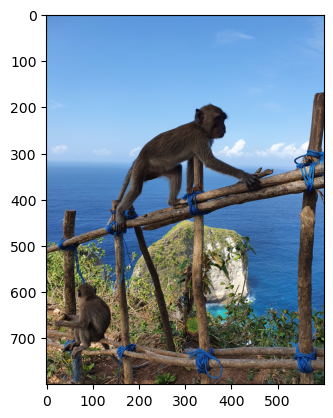

In [9]:
im_org = io.imread("data/NusaPenida.png")
plt.imshow(im_org)

## Playing with rotations

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


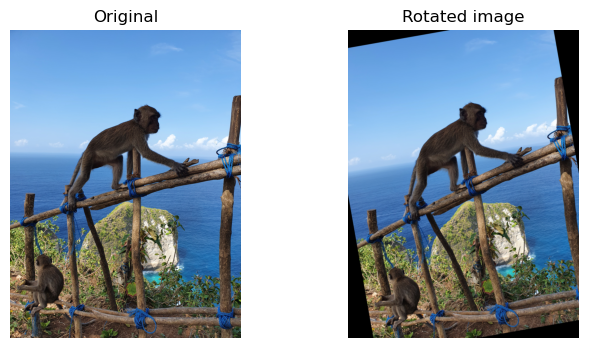

In [10]:
# angle in degrees - counter clockwise
rotation_angle = 10
rotated_img = rotate(im_org, rotation_angle)
show_comparison(im_org, rotated_img, "Rotated image")

### Change rotation centre

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


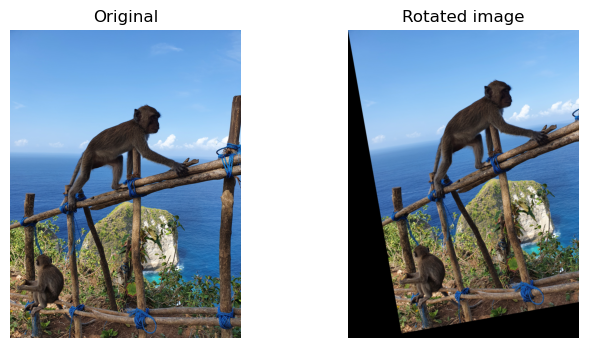

In [12]:
rot_center = [0, 0]
rotated_img = rotate(im_org, rotation_angle, center=rot_center)
show_comparison(im_org, rotated_img, "Rotated image")

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


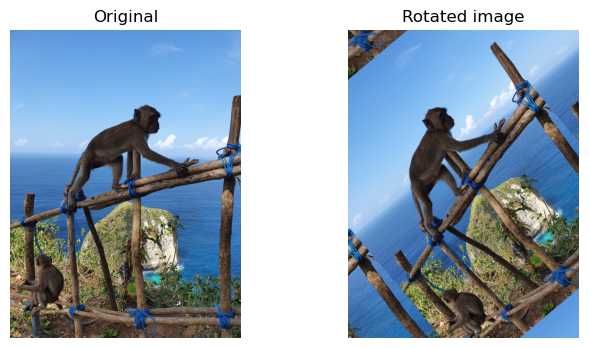

In [18]:
rotation_angle = 40
# Different modes wrap and reflect
rotated_img = rotate(im_org, rotation_angle, mode="wrap")
show_comparison(im_org, rotated_img, "Rotated image")

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


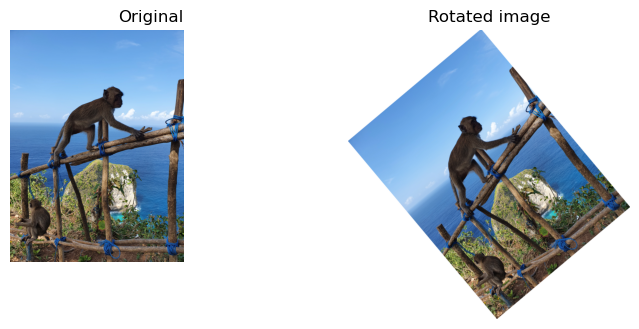

In [19]:
rotated_img = rotate(im_org, rotation_angle, resize=True, mode="constant", cval=1)
show_comparison(im_org, rotated_img, "Rotated image")

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


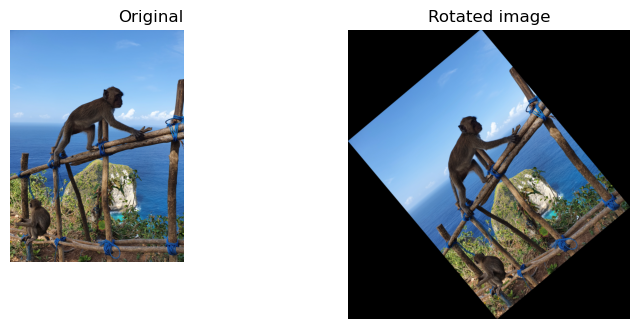

In [20]:
rotated_img = rotate(im_org, rotation_angle, resize=True)
show_comparison(im_org, rotated_img, "Rotated image")

## Euclidean image transformation 

In [21]:
# angle in radians - counter clockwise
rotation_angle = 10.0 * math.pi / 180.0
trans = [10, 20]
tform = EuclideanTransform(rotation=rotation_angle, translation=trans)
print(tform.params)

[[ 0.98480775 -0.17364818 10.        ]
 [ 0.17364818  0.98480775 20.        ]
 [ 0.          0.          1.        ]]


Note: The warp function actually does an inverse transformation of the image, since it uses the transform to find the pixels values in the input image that should be placed in the output image.

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


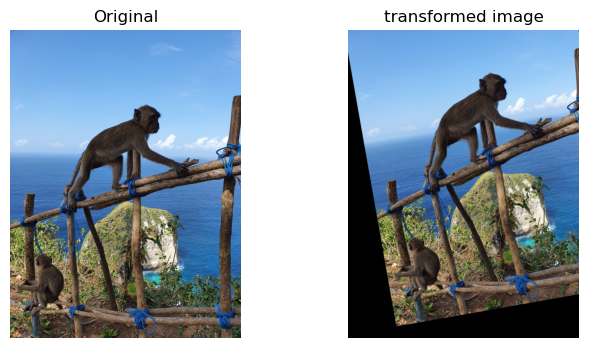

In [23]:
transformed_img = warp(im_org, tform)
show_comparison(im_org, transformed_img, "transformed image")

## Similarity transform

[[ 0.68936543 -0.12155372 10.        ]
 [ 0.12155372  0.68936543 20.        ]
 [ 0.          0.          1.        ]]


/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


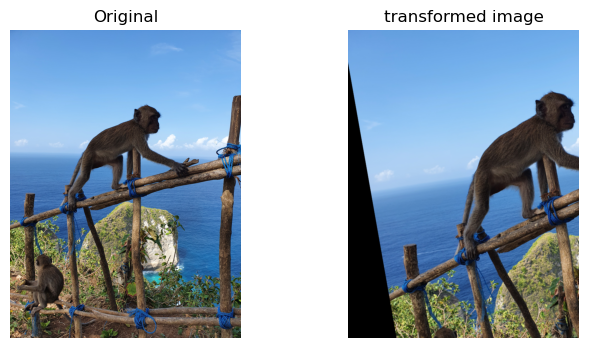

In [25]:
# angle in radians - counter clockwise
rotation_angle = 10.0 * math.pi / 180.0
trans = [10, 20]
scale_factor = 0.7
tform = SimilarityTransform(rotation=rotation_angle, translation=trans, scale=scale_factor)
print(tform.params)
transformed_img = warp(im_org, tform)
show_comparison(im_org, transformed_img, "transformed image")

## swirl transform

/tmp/ipykernel_55300/3391707519.py:9: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


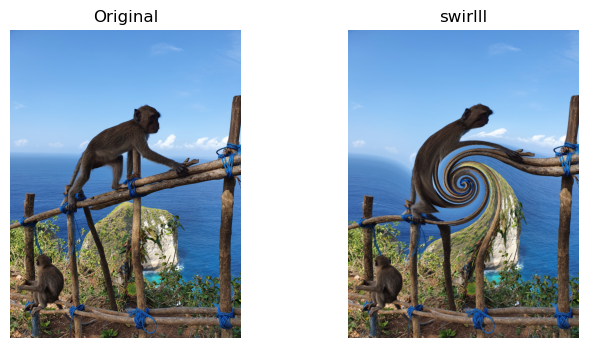

In [26]:
str = 10
rad = 300
swirl_img = swirl(im_org, strength=str, radius=rad)
show_comparison(im_org, swirl_img, "swirlll")

In [ ]:
str = 10
rad = 300
c = [500, 400]
swirl_img = swirl(im_org, strength=str, radius=rad, center=c)

## Landmark based registration

In [28]:
from skimage import img_as_float

/tmp/ipykernel_55300/4045126079.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(blend)
/tmp/ipykernel_55300/4045126079.py:5: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.show()


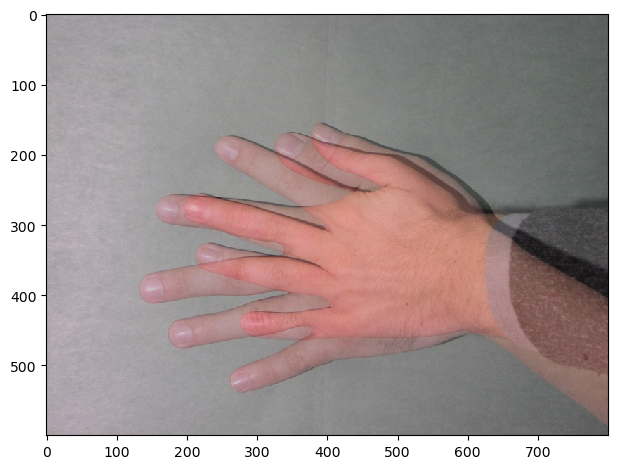

In [29]:
src_img = io.imread("data/Hand1.jpg")
dst_img = io.imread("data/Hand2.jpg")
blend = 0.5 * img_as_float(src_img) + 0.5 * img_as_float(dst_img)
io.imshow(blend)
io.show()

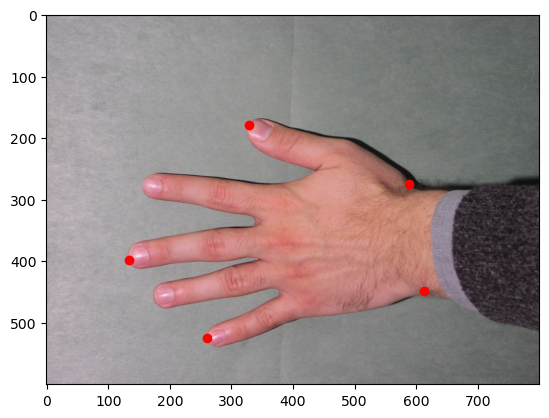

In [30]:
src = np.array([[588, 274], [328, 179], [134, 398], [260, 525], [613, 448]])

plt.imshow(src_img)
plt.plot(src[:, 0], src[:, 1], ".r", markersize=12)
plt.show()